# Multi-region Sparse Component Analysis (**mSCA**) - spiking data

**Note**: this notebook will cover all the same functionality discussed in `./quickstary.ipynb`, but now using spiking data. In other words, we're going to demonstrate the model's functionality on simulated data that hasn't been _presmoothed_ or _trial-averaged_ in any way.

**mSCA** is a dimensionality reduction tool specifically designed for analyzing data from multiple brain regions.

**mSCA** has three defining features:

1.  **Inferring latent factors that occur sparsely in time:** For example, it can demarcate movement-related activity from preparatory activity, facilitating interpretation.

2.  **Identifying region-specific or shared latent factors:** mSCA determines whether each inferred latent factor is unique to a given brain region or shared across multiple regions.

3.  **Quantifying time-delays for shared latent factors:** For latent factors shared across regions, mSCA identifies the time-delays at which they appear in each region, revealing the correlational flow of information between brain regions.

This notebook will guide you through the basic functionality of mSCA and should be copied and adapted to get started with your own data. We will have an additional notebook walking through more rigorous (but more time-intensive) analyses in `./full_demo.ipynb`.

## Required package installations
* Follow the installation instructions in `README.md` before running the code below.

## Data formatting and example
* In order to fit mSCA and infer latents, your data should be in the following format:
    ```
    X = { 
        "region_1": [trial_1, trial_2, ..., trial_M], 
        "region_2": [trial_1, trial_2, ..., trial_M]
    }
    ```
* The keys of `X` should correspond to the names of the regions in your dataset.
* The values of `X` should be lists of `np.float32` arrays of shape `(t_j x N_i)`.
    * `t_j` is the number of time-points on trial `j`.
    * `N_i` is the number of neurons in region `i`.
* We're now going to create a simulated dataset using a set of ground-truth latent factors we created, and assess mSCA's ability to recover the ground-truth latent factors and their corresponding time-delays.

[0, -1, -6, -10, 0]


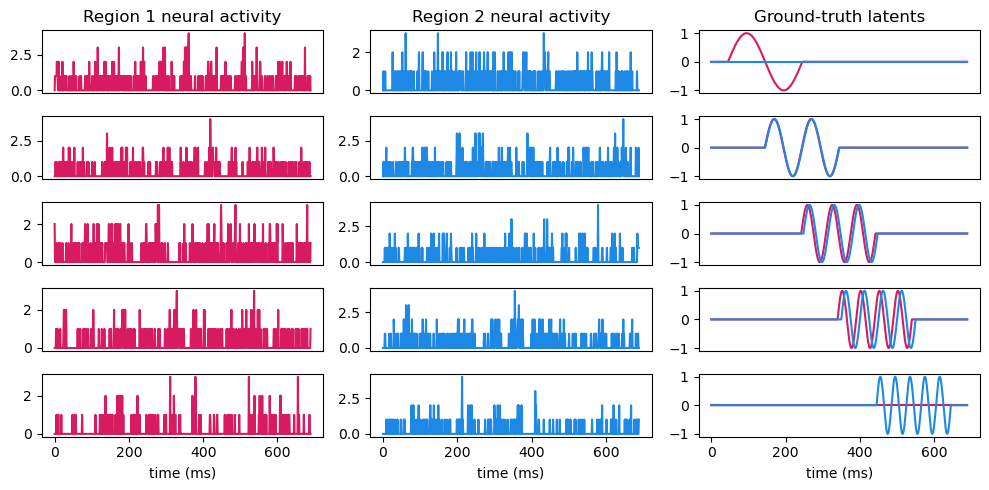

In [1]:
import matplotlib.pyplot as plt
from msca import *

# NOTE: we have manually made one of the time-delays in the ground-truth dataset
#       = 1 time bin, in order to showcase the high temporal resolution at which
#       mSCA performs.

# Generate noisy simulated firing-rates, ground-truth latents, and delays
X, Z_gt, delays_gt = simulate_single_trials(random_seed=2)

# Visualization + example accessing attributes of X
colors = ["#D81B60", "#1E88E5"]
num_viz = 5
fig, axs = plt.subplots(num_viz, 3, figsize=(10, 5))
for i in range(num_viz):
    axs[i, 0].plot(X["X0"][0][:, i], c=colors[0])
    axs[i, 1].plot(X["X1"][0][:, i], c=colors[1])
    axs[i, 2].plot(Z_gt["Z0"][:, i], c=colors[0])
    axs[i, 2].plot(Z_gt["Z1"][:, i], c=colors[1])

    if i == 0:
        axs[i, 0].set_title("Region 1 neural activity")
        axs[i, 1].set_title("Region 2 neural activity")
        axs[i, 2].set_title("Ground-truth latents")

    if i < num_viz-1:
        axs[i, 0].set_xticks([])
        axs[i, 1].set_xticks([])
        axs[i, 2].set_xticks([])
    else:
        axs[i, 0].set_xlabel("time (ms)")
        axs[i, 1].set_xlabel("time (ms)")
        axs[i, 2].set_xlabel("time (ms)")
fig.tight_layout()
print(delays_gt)

## Training mSCA

* We're now going to train mSCA

* If your data hasn't been pre-smoothed or trial-averaged in any way, add `loss_func="Poisson"` to the arguments passed into `mSCA()`.

* We have provided what we think are good defaults, but if you want to toggle any of the following hyperparameters `lam_sparse`, `lam_orthog`, or `lam_region`, you can pass your desired value as an argument to `mSCA()`. It's a generally a good idea to keep the values you use within the range [0.0, 1.0].

In [2]:
msca, losses = mSCA(n_components=5, loss_func="Poisson", n_epochs=6000).fit(X)

# Save trained mSCA model - do this before refining time-delays in case you want to try different thresholds
save_folder = "."
msca.save(f"{save_folder}/msca.pt")

/Users/andrewulmer/nuin/research/mSCA/msca/architectures.py:173: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


Using region-weights = {'X0': 1.0044547319412231, 'X1': 0.9955846667289734}
Using lam_sparse = 0.5212000012397766
Using lam_orthog = 100469.306640625
Using lam_region = 0.0


100%|██████████| 6000/6000 [27:36<00:00,  3.62it/s]


## Visualize the losses to ensure the model converged

Text(0.5, 0, 'training epoch')

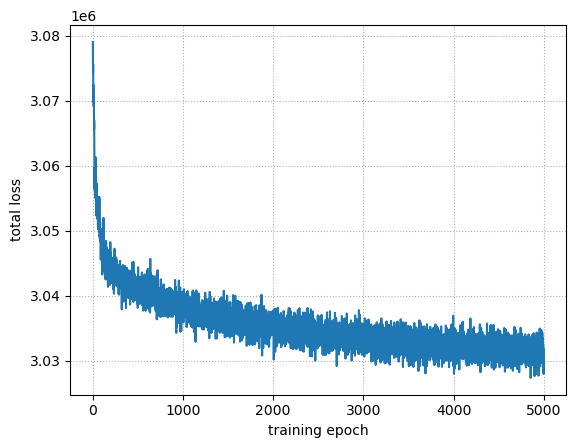

In [3]:
# Concatenate and sum the losses (reconstruction, latent sparsity, region, sparsity, and orthogonality)
loss = losses['total_loss']

# Plot the total loss up until the "post-hoc" scaling compensation stage
plt.plot(loss[:-msca.post_hoc_epoch])
plt.grid(ls=":");
plt.ylabel("total loss");
plt.xlabel("training epoch")

## Inferring latents with the trained mSCA model
* We're now going to use the trained mSCA model to infer latents and compare them to the ground-truth latents and corresponding time-delays.

* **Note**:
    * The recovered latents might appear a little bent when compared to the ground-truth. This is due to the non-linearities in the encoder. On real datasets (non-simulated), we've seen these non-linearities help find sparser, more interpretable latents.
    
    * Also, the inferred latents may be flipped in sign (+1 or -1) when compared to the ground-truth.

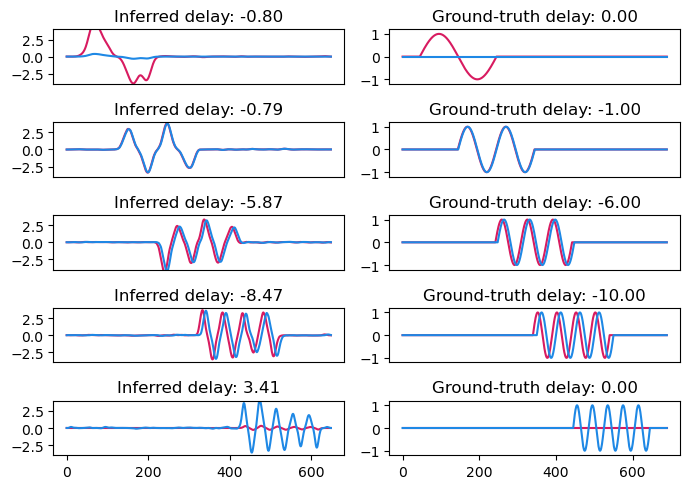

In [4]:
def plot_ordered_latents(Z, msca):
    # Let's order the latents for the first trial by deflection time
    idxs = detect_deflect(Z, msca, trial_num=0)

    # Reorder the inferred latents for the first trial by deflection time
    Z_reordered = {
        "X0": Z["X0"][0][:,idxs],
        "X1": Z["X1"][0][:,idxs]
    }

    colors = ["#D81B60", "#1E88E5"]
    # fig, axs = plt.subplots(5, 2, figsize=(7, 5))

    fig = plt.figure(figsize=(7, 5))

    # Create a grid with n_components rows and 3 columns
    gs = fig.add_gridspec(msca.n_components, 2, width_ratios=[1, 1])

    # Retrieve the time-delays
    delays = (msca.model.filters.mus.data[:, 1] - msca.model.filters.mus.data[:, 0])[idxs].tolist()

    # Iterate through latent dimensions and plot
    for i in range(5):

        ax = fig.add_subplot(gs[i,0])
        ax.plot(Z_reordered["X0"][:, i], c=colors[0])
        ax.plot(Z_reordered["X1"][:, i], c=colors[1])
        ax.set_title(f"Inferred delay: {delays[i]:.2f}")
        
        ax.set_ylim(-4,4)

        if i < 4:
            ax.set_xticks([])

        ax = fig.add_subplot(gs[i,1])
        ax.plot(Z_gt["Z0"][:, i], c=colors[0])
        ax.plot(Z_gt["Z1"][:, i], c=colors[1])
        ax.set_title(f"Ground-truth delay: {delays_gt[i]:.2f}")

        ax.set_ylim(-1.2, 1.2)

        if i < 4:
            ax.set_xticks([])

    fig.tight_layout()

# First infer the latents
Z = msca.transform(X)

# Plot the ordered latents
plot_ordered_latents(Z, msca)



## Validating the learned time-delays
* We don't want to interpret time-delays that do not generalize well to held-out data.

* To avoid this, and avoid holding out data from our analysis, we developed a bootstrapping approach that scores time-delays on how well they generalize to *pseudo*-held-out data.

    * The details of this will be covered in `full_demo.ipynb`.

* We can use the results from this approach to prune those time-delays that do not meaningfully improve our ability to reconstruct neural activity input to mSCA.

* Part of the pruning process involves setting a threshold value. A higher threshold value corresponds to a stricter criterion i.e.:

    * For a high threshold, a learned time-delay must substantially improve prediction performance of pseudo-held-out data.

    * For a lower threshold, a learned time-delay must only marginally improve prediction performance of pseudo-held-out data


100%|██████████| 5/5 [02:18<00:00, 27.63s/it]


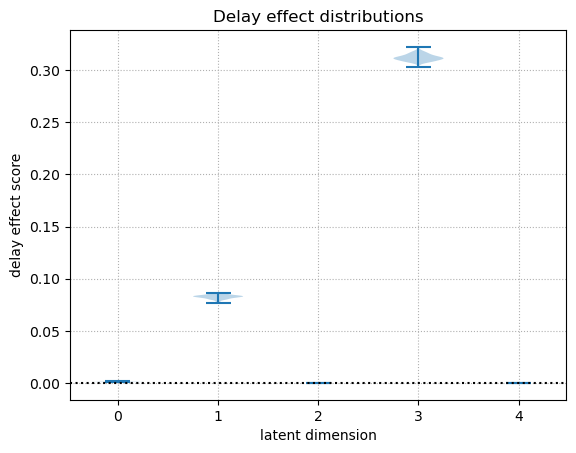

In [5]:
# Find the effect each time-delay has on reconstruction of pseudo-held-out
delay_effects = bootstrap_delays_decoder(msca, X, num_bootstraps=100)

# Set the threshold to use for pruning delays
threshold = 0.0001

# Plot the distribition of delay effects for each dimension
plt.violinplot(
    [v for v in delay_effects.values()], positions=[k for k in delay_effects.keys()]
)
plt.grid(ls=":")
plt.xlabel("latent dimension")
plt.ylabel("delay effect score")
plt.axhline(y=threshold, ls=":", c="k")
plt.title("Delay effect distributions")

# Iterate through dimensions and prune out those delays that don't fit our criterion
for i in range(msca.n_components):
    mean, lower = mean_confidence_interval(delay_effects[i])
    if lower <= threshold:
        msca.model.filters.mus.data[i] = 0

## Inferring latents with the refined mSCA model
* We're now going to visualize the latents once more, but this time using the refined time-delays.

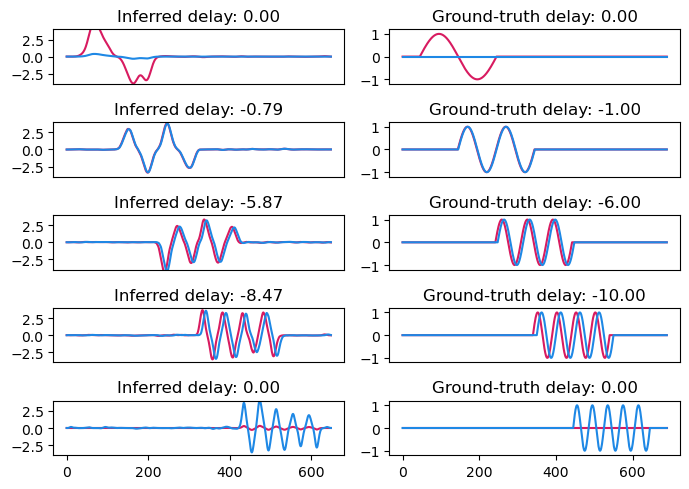

In [6]:
# First infer the latents
Z = msca.transform(X)

# Now plot the ordered latents
plot_ordered_latents(Z, msca)

## Check prediction quality
* We're now going to look and see how well the reconstructed neural activity captures the neural activity we input to the model
* The lines in black will be the predictions output by mSCA.

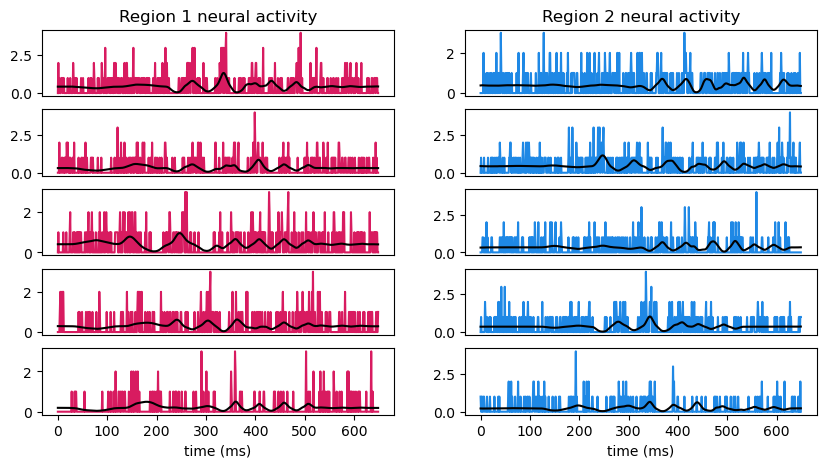

In [7]:
# Grab the reconstructions
X_hat = msca.predict(X)

# Visualization + example accessing attributes of X
num_viz = 5
fig, axs = plt.subplots(num_viz, 2, figsize=(10, 5))
for i in range(num_viz):
    axs[i, 0].plot(X["X0"][0][msca.trunc, i], c=colors[0])
    axs[i, 1].plot(X["X1"][0][msca.trunc, i], c=colors[1])

    axs[i, 0].plot(X_hat["X0"][0][:, i], c='k')
    axs[i, 1].plot(X_hat["X1"][0][:, i], c='k')

    if i == 0:
        axs[i, 0].set_title("Region 1 neural activity")
        axs[i, 1].set_title("Region 2 neural activity")

    if i < num_viz - 1:
        axs[i, 0].set_xticks([])
        axs[i, 1].set_xticks([])
    else:
        axs[i, 0].set_xlabel("time (ms)")
        axs[i, 1].set_xlabel("time (ms)")


## Sweeping over sparsity values
### The following is mainly relevant for beta testers at Northwestern

* The code we've provided above is a good starting point to get up and running with mSCA and ensure that your dataset is being loaded correctly.
* We would like to test how robust mSCA is to different hyperparameter settings, namely when using different values for `lam_sparse` and `lam_region`.
    * `lam_sparse` controls the sparsity of the latent representations.
    * `lam_region` controls the sparsity of the latents across brain regions.
* We've provided defaults that we believe work well across a few datasets, but would like to investigate the optimal hyperparameter settings for other datasets as well.
* We'll next demonstrate how to perform a sweep across `lam_sparse`, and include a few different options that may suit you depending on how much data / time you have.
* **Each successive option will take less time to run, but will be more involved in terms of things you have to do.**

### Sweeping on your local machine

In [8]:
# Add path to a folder to store the results of the sweep
sweep_folder = "./check_delete_later/test_sweep/"

# Set the number of components and number of epochs to use in each model fit in the sweep
n_components = 5
n_epochs = 4000

best_sparsity = sparsity_sweep_bootstrap(
    n_components, n_epochs, "Poisson", X, f"{sweep_folder}"
)

print(f"The model with the best sparsity value is stored at {sweep_folder}/msca_{best_sparsity}.pt")

Performing sparsity sweep 🧹 --> saving results to ./check_delete_later/test_sweep/


/Users/andrewulmer/nuin/research/mSCA/msca/architectures.py:173: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


Using region-weights = {'X0': 1.0044547319412231, 'X1': 0.9955846667289734}
Using lam_sparse = 0.0
Using lam_orthog = 100469.306640625
Using lam_region = 0.0


  2%|▏         | 66/4000 [00:20<20:37,  3.18it/s]


KeyboardInterrupt: 

### Sweeping using GPU node on Quest

### Sweeping using multiple short nodes on Quest

* TODO: add note about quest